<a href="https://colab.research.google.com/github/mad10116/BOOTCAMP-EDA-STUDY/blob/main/EDA_activity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### EDA Case Study

**Introduction**

This case study aims to give an idea of applying EDA in a real business scenario. In this case study, we will develop a basic understanding of risk analytics in banking and financial services and understand how data is used to minimize the risk of losing money while lending to customers.

**Business Understanding**

The loan providing companies find it hard to give loans to the people due to their insufficient or non-existent credit history. Because of that, some consumers use it as their advantage by becoming a defaulter. Suppose we work for a consumer finance company which specializes in lending various types of loans to urban customers. We will have to use EDA to analyze the patterns present in the data. This will ensure that the applicants capable of repaying the loan are not rejected.

When the company receives a loan application, the company has to decide for loan approval based on the applicant’s profile. Two types of risks are associated with the bank’s decision:

If the applicant is likely to repay the loan, then not approving the loan results in a loss of business to the company

If the applicant is not likely to repay the loan, i.e. he/she is likely to default, then approving the loan may lead to a financial loss for the company.

The data given below contains the information about the loan application at the time of applying for the loan. It contains two types of scenarios:

The client with payment difficulties: he/she had late payment more than X days on at least one of the first Y instalments of the loan in our sample,

All other cases: All other cases when the payment is paid on time.

When a client applies for a loan, there are four types of decisions that could be taken by the client/company):

Approved: The Company has approved loan Application

Cancelled: The client cancelled the application sometime during approval. Either the client changed her/his mind about the loan or in some cases due to a higher risk of the client he received worse pricing which he did not want.

Refused: The company had rejected the loan (because the client does not meet their requirements etc.).

Unused offer: Loan has been cancelled by the client but on different stages of the process.

In this case study, we will use EDA to understand how consumer attributes and loan attributes influence the tendency of default.

**Business Objectives**

This case study aims to identify patterns which indicate if a client has difficulty paying their installments which may be used for taking actions such as denying the loan, reducing the amount of loan, lending (to risky applicants) at a higher interest rate, etc. This will ensure that the consumers capable of repaying the loan are not rejected. Identification of such applicants using EDA is the aim of this case study.

In other words, the company wants to understand the driving factors (or driver variables) behind loan default, i.e. the variables which are strong indicators of default. The company can utilize this knowledge for its portfolio and risk assessment.

**Data Understanding**

This dataset has 3 files as explained below:

`application_data.csv` contains all the information of the client at the time of application.
The data is about whether a client has payment difficulties.

`previous_application.csv` contains information about the client’s previous loan data. It contains the data whether the previous application had been Approved, Cancelled, Refused or Unused offer.

`columns_description.xlsx` is data dictionary which describes the meaning of the variables.


I have given a link to the data files in a drive folder [here](https://drive.google.com/drive/folders/1YpPjU4Y12MPrMdWaNDa6rS2MNirh2FG3?usp=sharing).  I suggest unzipping them and putting them in your google drive, and link to them directly using colab and its "mount drive" functionality.

In [ ]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!apt-get install git-lfs

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git-lfs is already the newest version (3.0.2-1ubuntu0.3).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
!git lfs install
!git clone https://github.com/mad10116/BOOTCAMP-EDA-STUDY.git


Git LFS initialized.
Cloning into 'BOOTCAMP-EDA-STUDY'...
remote: Enumerating objects: 20, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 20 (delta 2), reused 20 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (20/20), 4.15 KiB | 4.15 MiB/s, done.
Resolving deltas: 100% (2/2), done.
Filtering content: 100% (3/3), 544.67 MiB | 6.66 MiB/s, done.


In [ ]:
app_data = pd.read_csv('/content/BOOTCAMP-EDA-STUDY/application_data.csv')
previous_application = pd.read_csv('/content/BOOTCAMP-EDA-STUDY/previous_application.csv')
col_desc = pd.read_excel('/content/BOOTCAMP-EDA-STUDY/columns_description.xlsx')

# APPLICATION DATA ANALYSIS

In [ ]:
app_data.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
app_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [ ]:
app_data.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


CLEANING UP THE DATA

In [ ]:
# The 20 high-impact columns we selected
driver_columns = [
    'TARGET', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE',
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
    'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT',
    'DEF_30_CNT_SOCIAL_CIRCLE', 'AMT_GOODS_PRICE'
]

app_data_clean = app_data[driver_columns].copy()

# Check missing values for our new driver-column dataset
missing_clean = app_data_clean.isna().sum() / len(app_data_clean) * 100
missing_clean = missing_clean[missing_clean > 0].sort_values(ascending=False)

print("Missing data in our Driver Columns (%):")
print(missing_clean)


Missing data in our Driver Columns (%):
EXT_SOURCE_1                56.381073
OCCUPATION_TYPE             31.345545
EXT_SOURCE_3                19.825307
DEF_30_CNT_SOCIAL_CIRCLE     0.332021
EXT_SOURCE_2                 0.214626
AMT_GOODS_PRICE              0.090403
AMT_ANNUITY                  0.003902
CNT_FAM_MEMBERS              0.000650
dtype: float64


In [ ]:
#Check whether missingess leads to default
app_data_clean["EXT1_missing"] = app_data_clean["EXT_SOURCE_1"].isna()
print(app_data_clean.groupby("EXT1_missing")["TARGET"].mean())

app_data_clean["EXT3_missing"] = app_data_clean["EXT_SOURCE_3"].isna()
print(app_data_clean.groupby("EXT3_missing")["TARGET"].mean())

app_data_clean["OCC_missing"] = app_data_clean["OCCUPATION_TYPE"].isna()
print(app_data_clean.groupby("OCC_missing")["TARGET"].mean())

EXT1_missing
False    0.074955
True     0.085195
Name: TARGET, dtype: float64
EXT3_missing
False    0.077665
True     0.093119
Name: TARGET, dtype: float64
OCC_missing
False    0.087851
True     0.065131
Name: TARGET, dtype: float64


In [ ]:
import numpy as np

# A) Keep "missingness flags" (because missingness relates to default)
app_data_clean["EXT1_missing"] = app_data_clean["EXT_SOURCE_1"].isna()
app_data_clean["EXT3_missing"] = app_data_clean["EXT_SOURCE_3"].isna()
app_data_clean["OCC_missing"]  = app_data_clean["OCCUPATION_TYPE"].isna()
app_data_clean["OCCUPATION_TYPE"] = app_data_clean["OCCUPATION_TYPE"].fillna("Unknown")

# B) Fix weird day-related numbers(convert to yrs/ abs #)
app_data_clean["DAYS_EMPLOYED_ANOM"] = (app_data_clean["DAYS_EMPLOYED"] == 365243)
app_data_clean["DAYS_EMPLOYED"] = app_data_clean["DAYS_EMPLOYED"].replace(365243, np.nan)
app_data_clean["AGE_YEARS"] = app_data_clean["DAYS_BIRTH"].abs() / 365
app_data_clean["YEARS_EMPLOYED"] = app_data_clean["DAYS_EMPLOYED"].abs() / 365
app_data_clean = app_data_clean.drop(columns=["DAYS_BIRTH", "DAYS_EMPLOYED"])

# C) Fill missing numeric values with median (so charts/groupby won't break)
columns_to_fill = [
    "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3",
    "DEF_30_CNT_SOCIAL_CIRCLE", "AMT_GOODS_PRICE",
    "AMT_ANNUITY", "CNT_FAM_MEMBERS", "YEARS_EMPLOYED"
]
for col in columns_to_fill:
    app_data_clean[col] = app_data_clean[col].fillna(app_data_clean[col].median())

# Check
app_data_clean.shape

(307511, 25)

CATEGORICAL VARIABLE ANALYSIS

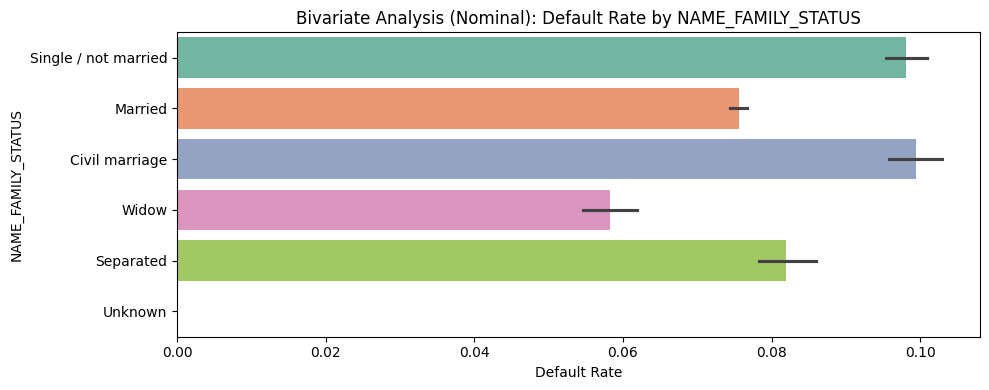

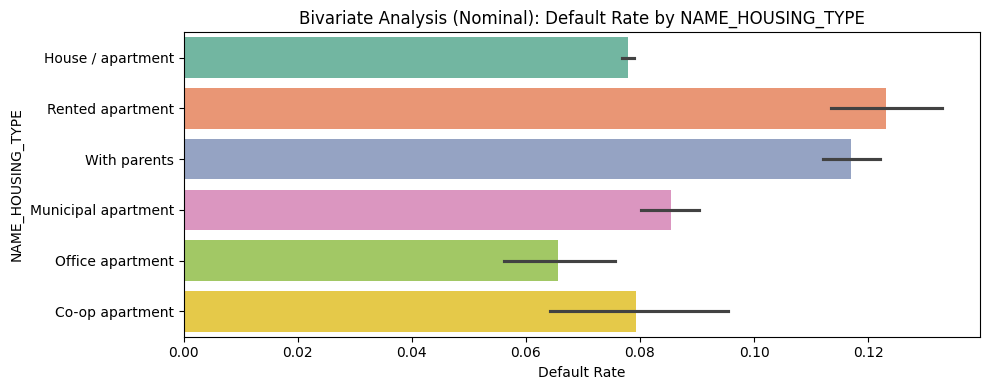

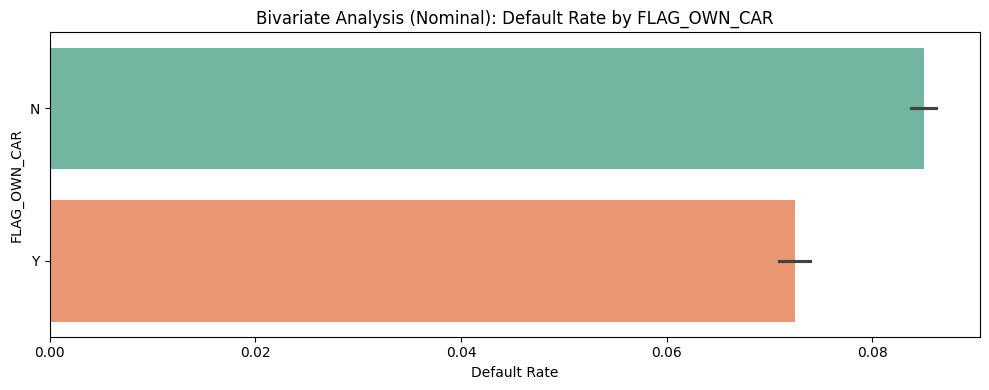

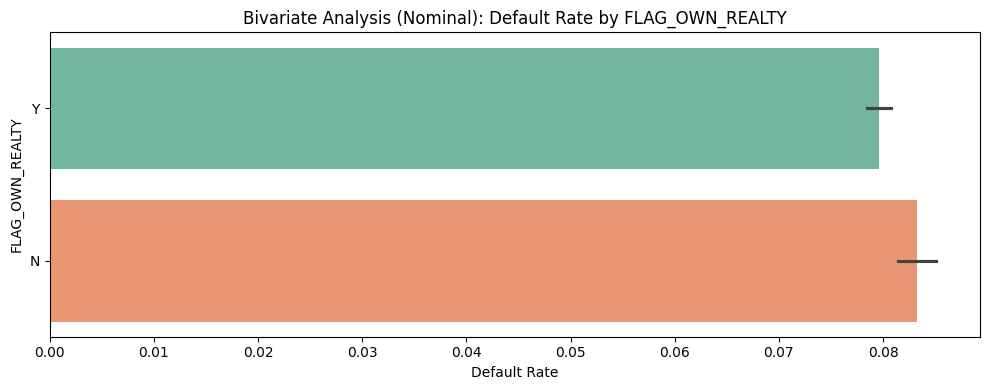

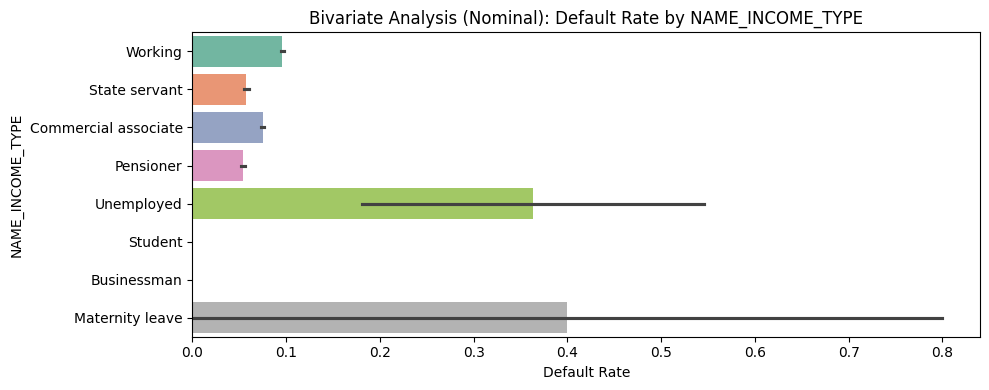

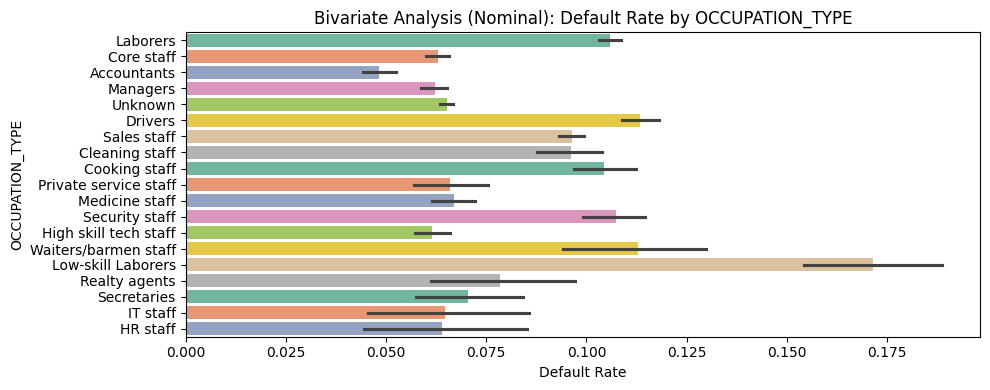

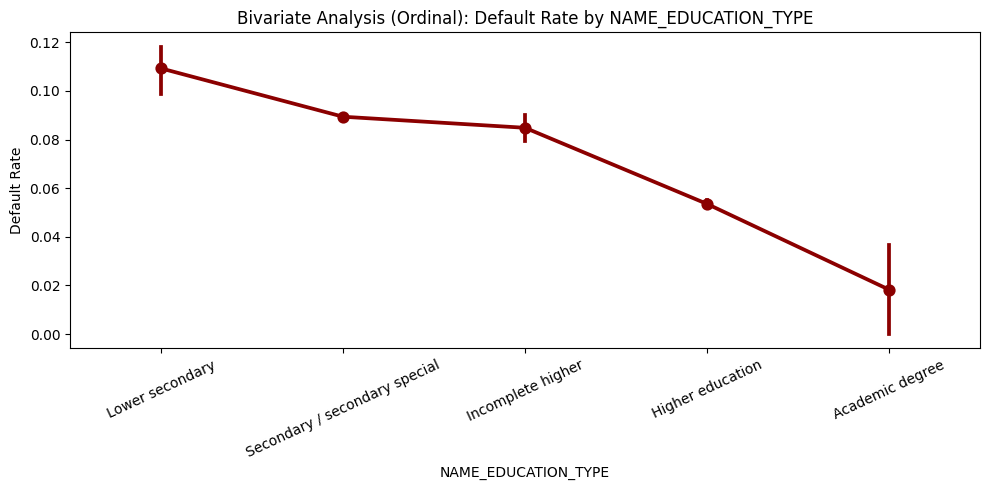

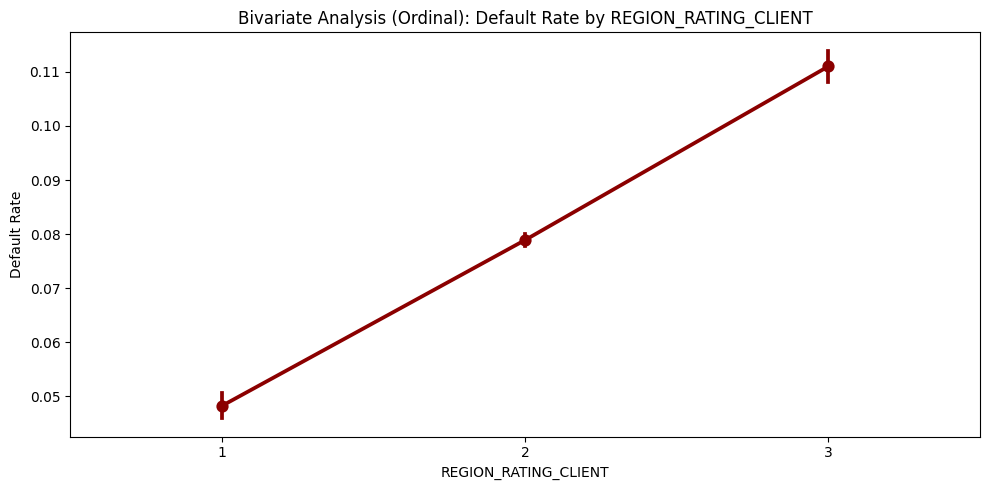

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. NOMINAL VARIABLES -> BAR PLOTS
nominal_cols = [
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY',
    'NAME_INCOME_TYPE',
    'OCCUPATION_TYPE'
]

for col in nominal_cols:
    plt.figure(figsize=(10, 4))
    sns.barplot(
        data=app_data_clean,
        y=col,
        x='TARGET',
        palette='Set2',
        hue=col,
        legend=False
    )
    plt.title(f'Bivariate Analysis (Nominal): Default Rate by {col}', fontsize=12)
    plt.xlabel('Default Rate')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


# 2. ORDINAL VARIABLES -> POINT PLOTS
ordinal_cols_dict = {
    'NAME_EDUCATION_TYPE': [
        'Lower secondary',
        'Secondary / secondary special',
        'Incomplete higher',
        'Higher education',
        'Academic degree'
    ],
    'REGION_RATING_CLIENT': [1, 2, 3]
}

for col, cat_order in ordinal_cols_dict.items():
    plt.figure(figsize=(10, 5))
    sns.pointplot(
        data=app_data_clean,
        x=col,
        y='TARGET',
        order=cat_order,
        color='darkred',
    )
    plt.title(f'Bivariate Analysis (Ordinal): Default Rate by {col}', fontsize=12)
    plt.ylabel('Default Rate')
    plt.xlabel(col)

    if col == 'NAME_EDUCATION_TYPE':
        plt.xticks(rotation=25)

    plt.tight_layout()
    plt.show()

# PREVIOUS APPLICATION DATA ANALYSIS

In [ ]:
previous_application.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


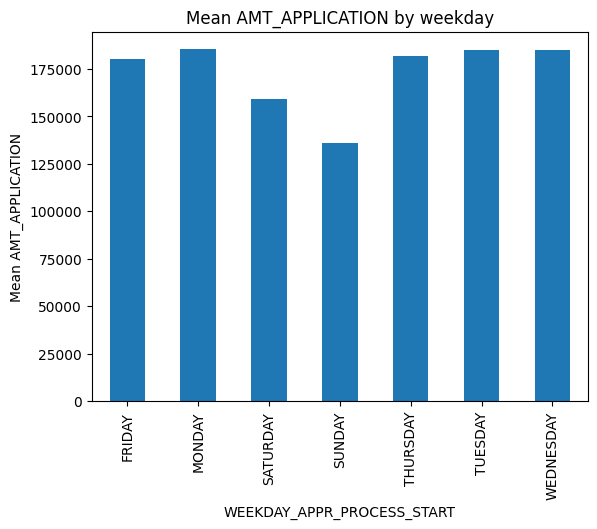

In [ ]:
# What weekdays see the highest nominal value applications being filed?

amt_per_weekday = (previous_application.groupby("WEEKDAY_APPR_PROCESS_START")["AMT_APPLICATION"].mean())

amt_per_weekday_graph = amt_per_weekday.plot(kind="bar", title="Mean AMT_APPLICATION by weekday")
amt_per_weekday_graph.set_xlabel("WEEKDAY_APPR_PROCESS_START")
amt_per_weekday_graph.set_ylabel("Mean AMT_APPLICATION")
plt.show()


In [ ]:
# Within contract types, how is the nominal value of loan applications different by yield group?

previous_application.groupby(['NAME_CONTRACT_TYPE', 'NAME_YIELD_GROUP'])['AMT_APPLICATION'].mean().sort_values(ascending=False)


NAME_CONTRACT_TYPE  NAME_YIELD_GROUP
Cash loans          low_action          1.152478e+06
                    low_normal          6.550065e+05
                    middle              3.485112e+05
                    high                2.029449e+05
Consumer loans      low_action          1.355299e+05
                    low_normal          1.225598e+05
                    middle              1.018861e+05
Revolving loans     XNA                 9.781624e+04
Consumer loans      XNA                 6.905177e+04
                    high                5.609388e+04
Cash loans          XNA                 6.511409e+02
XNA                 XNA                 0.000000e+00
Name: AMT_APPLICATION, dtype: float64

<Axes: xlabel='NAME_CONTRACT_TYPE', ylabel='AMT_APPLICATION'>

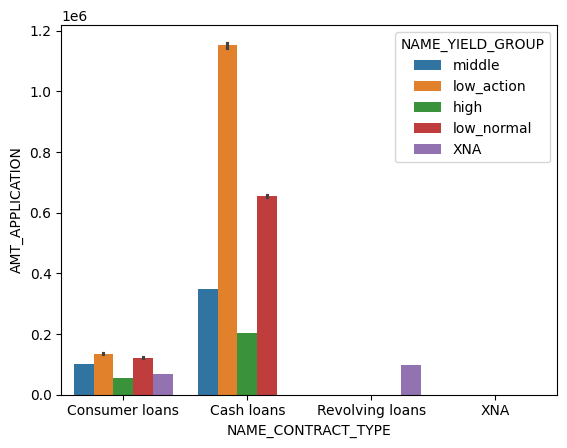

In [ ]:
# Graphical view of the above question.

sns.barplot(data = previous_application, x = 'NAME_CONTRACT_TYPE', y = 'AMT_APPLICATION', hue = 'NAME_YIELD_GROUP')

<Axes: xlabel='AMT_APPLICATION', ylabel='AMT_ANNUITY'>

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


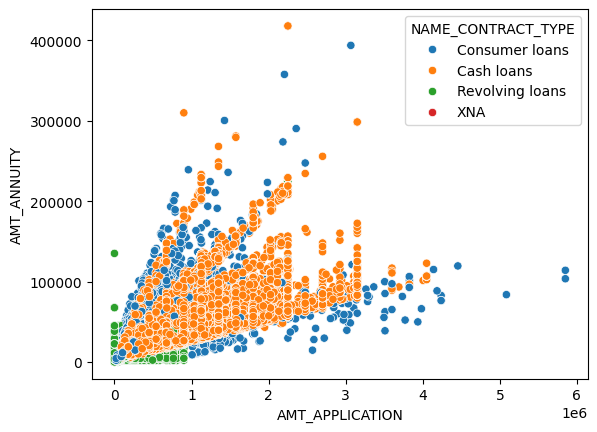

In [ ]:
# Is there a relationship between the loan application amount and the annuity payment, and does it differ by contract type?

sns.scatterplot( data = previous_application, x = 'AMT_APPLICATION', y = 'AMT_ANNUITY', hue = 'NAME_CONTRACT_TYPE')

In [ ]:
# Amount of previous applications per contract type

previous_application.groupby("NAME_CONTRACT_TYPE")["AMT_APPLICATION"].mean().sort_values(ascending=False)


,AMT_APPLICATION
NAME_CONTRACT_TYPE,
Cash loans,274760.431648
Revolving loans,97816.236334
Consumer loans,93787.825036
XNA,0.000000


In [ ]:
# What is the distribution of the credit ratio — how much credit do applicants typically receive relative to what they applied for?

previous_application['CREDIT_RATIO'] = previous_application['AMT_CREDIT'] / previous_application['AMT_APPLICATION']
previous_application.groupby(['NAME_CONTRACT_TYPE', 'NAME_YIELD_GROUP'])['CREDIT_RATIO'].mean().sort_values(ascending=False)

NAME_CONTRACT_TYPE  NAME_YIELD_GROUP
Revolving loans     XNA                      inf
Cash loans          high                1.130180
                    middle              1.121084
                    low_normal          1.115333
                    low_action          1.091024
Consumer loans      low_action          1.054496
Cash loans          XNA                 1.000000
Consumer loans      XNA                 1.000000
                    low_normal          0.971531
                    middle              0.964321
                    high                0.962938
XNA                 XNA                      NaN
Name: CREDIT_RATIO, dtype: float64

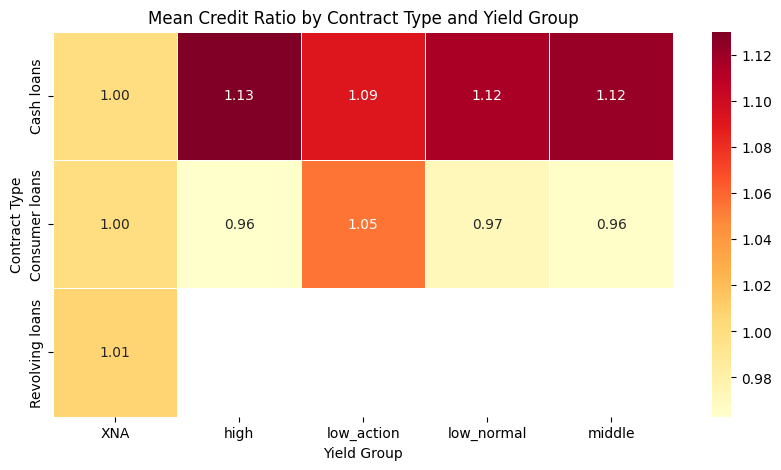

In [ ]:
# Graphical view of the above question.

valid_rows = previous_application[previous_application['CREDIT_RATIO']<120] #(Segregating only for numerical data as non-numeric data would have an infinitely large credit ratio or be undefined)
hmap_credit = valid_rows.groupby(['NAME_CONTRACT_TYPE', 'NAME_YIELD_GROUP'])['CREDIT_RATIO'].mean().unstack()

plt.figure(figsize=(10, 5))
sns.heatmap(hmap_credit, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
plt.title('Mean Credit Ratio by Contract Type and Yield Group')
plt.ylabel('Contract Type')
plt.xlabel('Yield Group')
plt.show()

<Axes: xlabel='AMT_APPLICATION', ylabel='CREDIT_RATIO'>

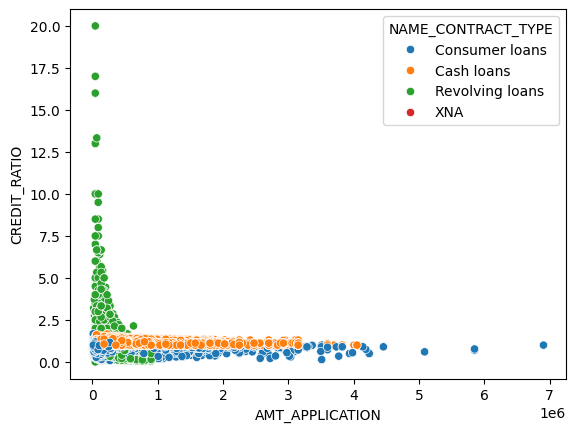

In [ ]:
# How does the application amount relate to the credit ratio across different contract types?

sns.scatterplot( data = previous_application, x = 'AMT_APPLICATION', y = 'CREDIT_RATIO', hue = 'NAME_CONTRACT_TYPE')

<Axes: xlabel='AMT_DOWN_PAYMENT', ylabel='CREDIT_RATIO'>

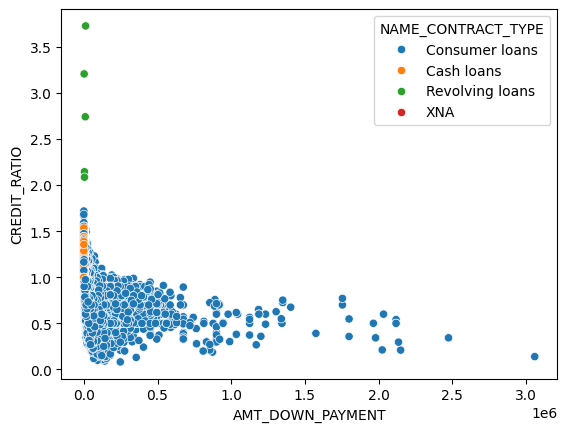

In [ ]:
# Does a higher down payment lead to a lower credit ratio, and does this vary by contract type?
sns.scatterplot( data = previous_application, x='AMT_DOWN_PAYMENT',y='CREDIT_RATIO',hue='NAME_CONTRACT_TYPE')

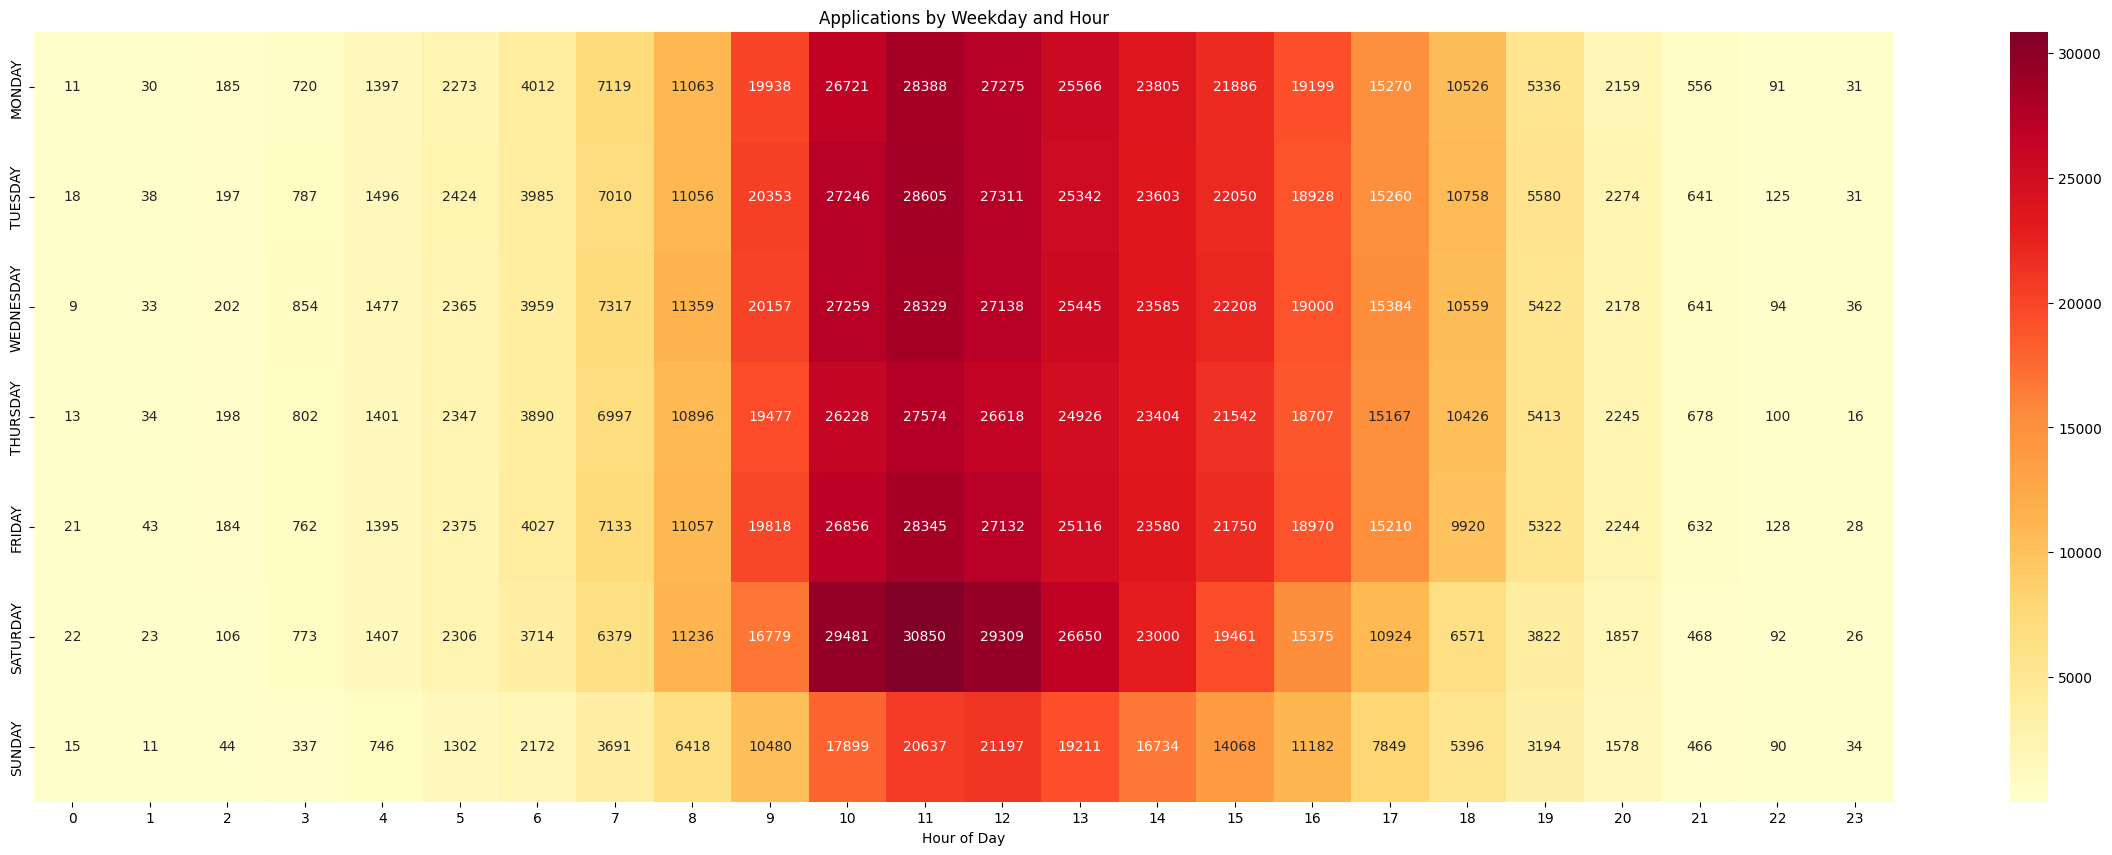

In [ ]:
# When are loan applications most frequently submitted, by day of week and time of day?
hmap_data = previous_application.groupby(['WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START']).size().unstack()

weekday_order = ['MONDAY','TUESDAY','WEDNESDAY','THURSDAY','FRIDAY','SATURDAY','SUNDAY']
hmap_data = hmap_data.reindex(weekday_order)

plt.figure(figsize=(30, 10))
sns.heatmap(hmap_data, cmap='YlOrRd', annot=True, fmt = '.0f')
plt.title('Applications by Weekday and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('')
plt.show()

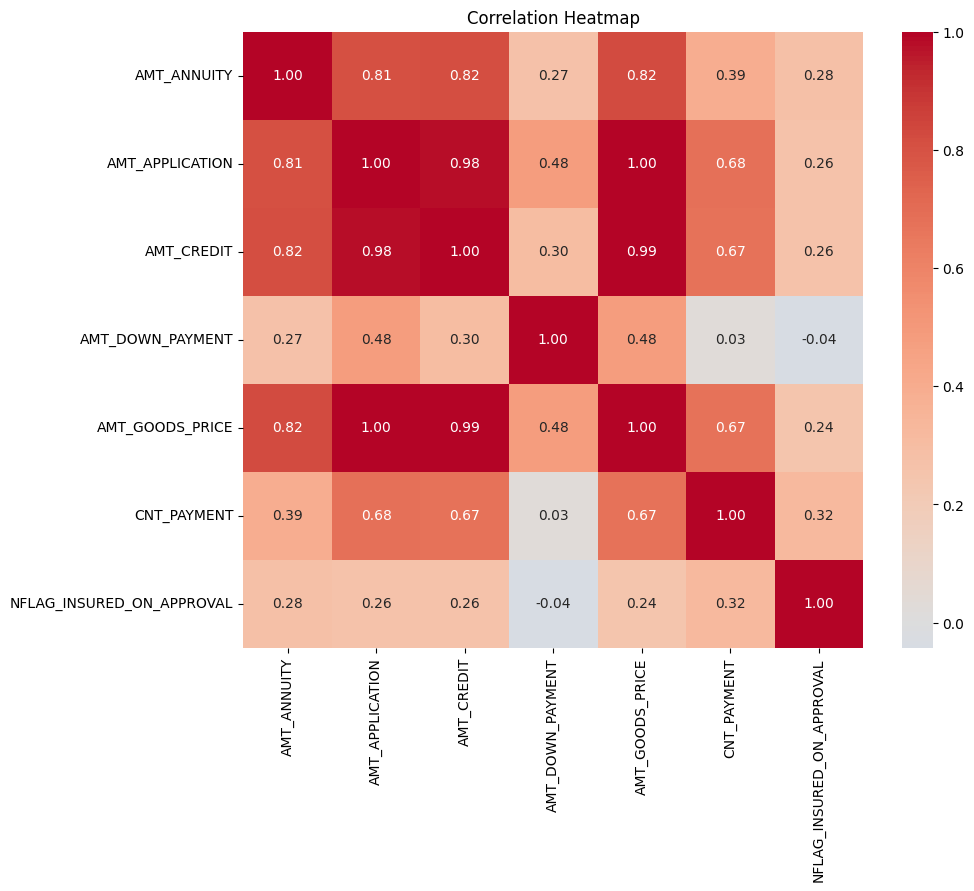

In [ ]:
# Which loan amount variables are most strongly correlated with each other?
cols = ['AMT_ANNUITY', 'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT',
        'AMT_GOODS_PRICE', 'CNT_PAYMENT', 'NFLAG_INSURED_ON_APPROVAL']

corr = previous_application[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

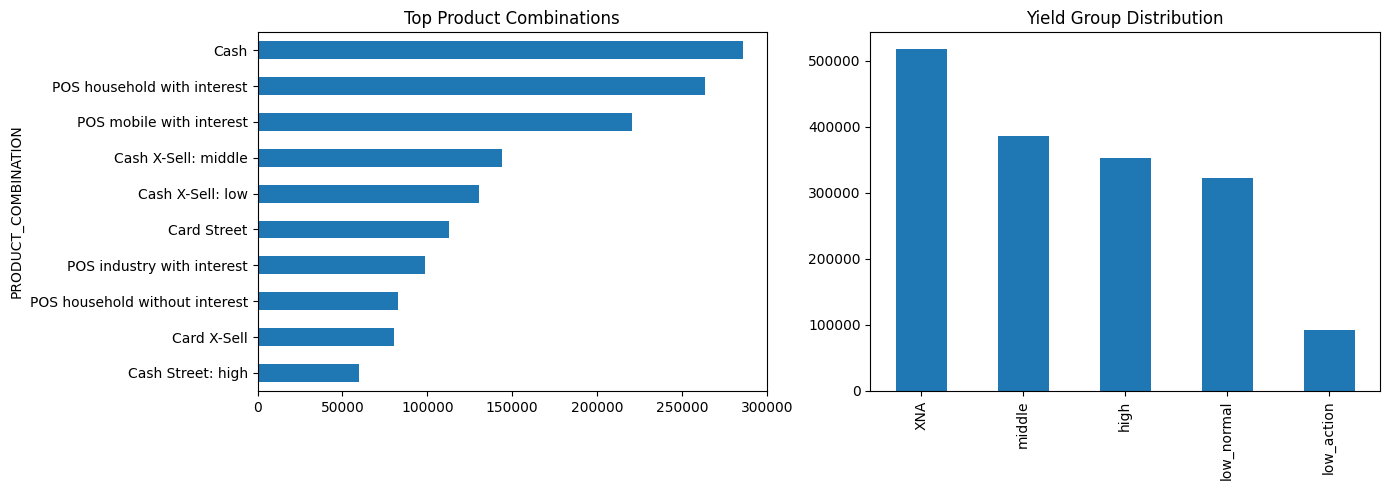

In [ ]:
# What are the most common loan product combinations, and how are loans distributed across yield groups?

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

previous_application['PRODUCT_COMBINATION'].value_counts().head(10).plot(kind='barh', ax=axes[0])
axes[0].set_title('Top Product Combinations')
axes[0].invert_yaxis()

previous_application['NAME_YIELD_GROUP'].value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Yield Group Distribution')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

In [ ]:
for col in app_data_clean.columns:
  app_data_clean.groupby(col)['TARGET'].mean()
import matplotlib.pyplot as plt
import seaborn as sns
numeric_cols = appdata.select_dtypes(include=['number']).columns

columns_to_process = [col for col in ['EXT_SOURCE_1','EXT_SOURCE_2','AGE_YEARS','EXT_SOURCE_3','DEF_30_CNT_SOCIAL_CIRCLE','CNT_CHILDREN','CNT_FAM_MEMBERS','AMT_ANNUITY','AMT_GOODS_PRICE','AMT_INCOME_TOTAL','AMT_CREDIT','YEARS_EMPLOYED'] if col in numeric_cols]

for col in columns_to_process:
  target_means = appdata.groupby('TARGET')[col].mean()
  print(target_means)

  if 0 in target_means.index and 1 in target_means.index:
    diff = (target_means.loc[1] - target_means.loc[0]) / appdata[col].mean()
    print('The DIFFERENCE IS', format((diff*100),'.2f')+"%")
  else:
    print(f"Cannot calculate difference for {col} as TARGET 0 or 1 is missing.")
  print()

TARGET
0    0.508396
1    0.457791
Name: EXT_SOURCE_1, dtype: float64
The DIFFERENCE IS -10.03%

TARGET
0    0.52357
1    0.41126
Name: EXT_SOURCE_2, dtype: float64
The DIFFERENCE IS -21.83%

TARGET
0    44.214182
1    40.780351
Name: AGE_YEARS, dtype: float64
The DIFFERENCE IS -7.82%

TARGET
0    0.523767
1    0.423775
Name: EXT_SOURCE_3, dtype: float64
The DIFFERENCE IS -19.39%

TARGET
0    0.138663
1    0.191702
Name: DEF_30_CNT_SOCIAL_CIRCLE, dtype: float64
The DIFFERENCE IS 37.10%

TARGET
0    0.412946
1    0.463807
Name: CNT_CHILDREN, dtype: float64
The DIFFERENCE IS 12.20%

TARGET
0    2.150152
1    2.181269
Name: CNT_FAM_MEMBERS, dtype: float64
The DIFFERENCE IS 1.45%

TARGET
0    27163.527386
1    26481.744290
Name: AMT_ANNUITY, dtype: float64
The DIFFERENCE IS -2.52%

TARGET
0    542652.484651
1    488939.444955
Name: AMT_GOODS_PRICE, dtype: float64
The DIFFERENCE IS -9.98%

TARGET
0    169077.722266
1    165611.760906
Name: AMT_INCOME_TOTAL, dtype: float64
The DIFFERENCE IS 

In [ ]:
results_data = []

for col in columns_to_process:
    target_means = app_data_clean.groupby('TARGET')[col].mean()
    mean0 = target_means.get(0, None) # Use .get() to handle cases where a target might be missing
    mean1 = target_means.get(1, None)

    difference = None
    if mean0 is not None and mean1 is not None:
        overall_mean = app_data_clean[col].mean()
        if overall_mean != 0: # Avoid division by zero
            difference = (mean1 - mean0) / overall_mean * 100

    results_data.append({
        'column_name': col,
        'mean0': mean0,
        'mean1': mean1,
        'difference_percent': difference
    })

diff_df = pd.DataFrame(results_data).set_index('column_name')
display(diff_df.head())
display(diff_df.tail())

,mean0,mean1,difference_percent
column_name,,,
EXT_SOURCE_1,0.508396,0.457791,-10.034385
EXT_SOURCE_2,0.523570,0.411260,-21.828897
AGE_YEARS,44.214182,40.780351,-7.815356
EXT_SOURCE_3,0.523767,0.423775,-19.389873
DEF_30_CNT_SOCIAL_CIRCLE,0.138663,0.191702,37.104775


,mean0,mean1,difference_percent
column_name,,,
AMT_ANNUITY,27163.527386,26481.744290,-2.515017
AMT_GOODS_PRICE,542652.484651,488939.444955,-9.977970
AMT_INCOME_TOTAL,169077.722266,165611.760906,-2.053320
AMT_CREDIT,602648.282002,557778.527674,-7.490452
YEARS_EMPLOYED,6.278687,4.917300,-22.068966


,mean0,mean1,difference_percent
column_name,,,
EXT_SOURCE_1,0.508396,0.457791,-10.034385
EXT_SOURCE_2,0.523570,0.411260,-21.828897
AGE_YEARS,44.214182,40.780351,-7.815356
EXT_SOURCE_3,0.523767,0.423775,-19.389873
DEF_30_CNT_SOCIAL_CIRCLE,0.138663,0.191702,37.104775


,mean0,mean1,difference_percent
column_name,,,
AMT_ANNUITY,27163.527386,26481.744290,-2.515017
AMT_GOODS_PRICE,542652.484651,488939.444955,-9.977970
AMT_INCOME_TOTAL,169077.722266,165611.760906,-2.053320
AMT_CREDIT,602648.282002,557778.527674,-7.490452
YEARS_EMPLOYED,6.278687,4.917300,-22.068966


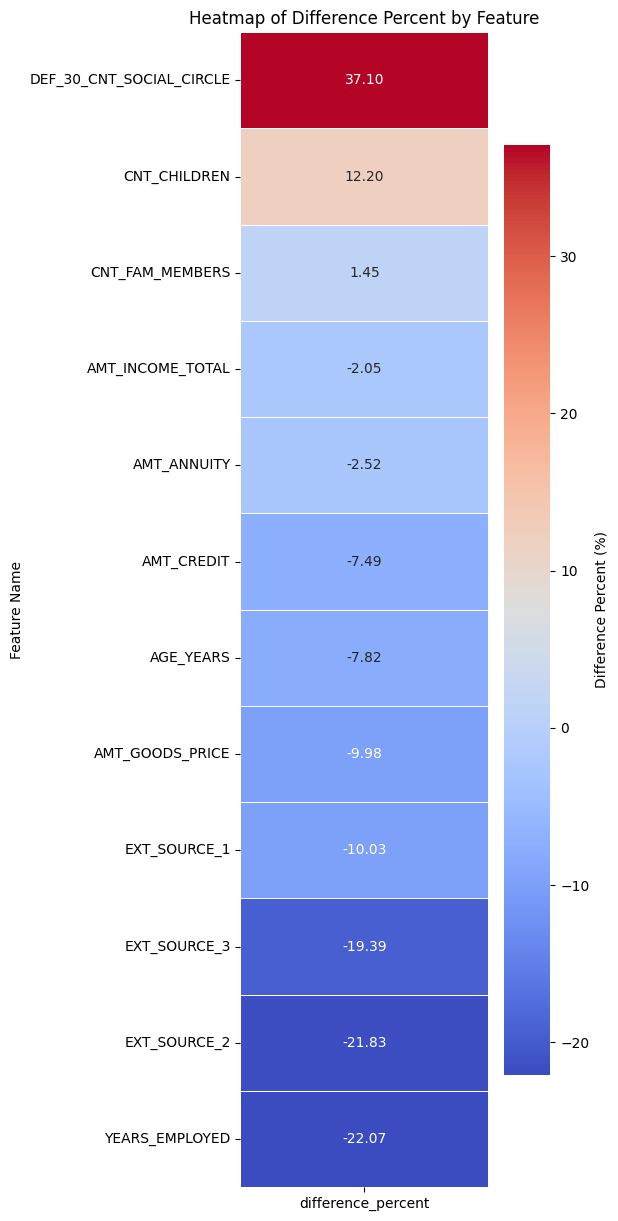

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the DataFrame by difference_percent to highlight the most impactful features
df_sorted = diff_df.sort_values(by='difference_percent', ascending=False)

# Create a heatmap of the difference_percent column
plt.figure(figsize=(4, 15)) # Adjust figure size as needed
sns.heatmap(df_sorted[['difference_percent']], annot=True, cmap='coolwarm', fmt=".2f",
            linewidths=.5, cbar_kws={'label': 'Difference Percent (%)'})
plt.title('Heatmap of Difference Percent by Feature')
plt.ylabel('Feature Name')
plt.show()